In [3]:
import os
from pathlib import Path
import pandas as pd

# Update this path to where you extracted the GIFs
GIF_DIR = r"D:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\Data\gifgif-images-v1"

# Check what's in the directory
if os.path.exists(GIF_DIR):
    gif_files = list(Path(GIF_DIR).rglob("*.gif"))
    print(f" Found {len(gif_files)} GIF files")
    print(f" Directory: {GIF_DIR}")
    
    # Show sample filenames
    print("\nSample GIF files:")
    for gif in gif_files[:5]:
        print(f"  - {gif.name} ({os.path.getsize(gif) / 1024:.1f} KB)")
else:
    print(f" Directory not found: {GIF_DIR}")
    print("Please update GIF_DIR to the correct path")

 Found 6142 GIF files
 Directory: D:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\Data\gifgif-images-v1

Sample GIF files:
  - 1000WjcUQeqOaY.gif (386.6 KB)
  - 100KE3jcx3ZKM.gif (493.3 KB)
  - 100v69Oj1OFjC8.gif (996.7 KB)
  - 100YmlniUkSv84.gif (469.8 KB)
  - 101htdn61ek6QM.gif (1113.2 KB)


In [5]:
# Check what the GIF filenames actually look like vs what we're searching for
import pandas as pd
from pathlib import Path

# Get actual GIF filenames
gif_files = list(Path(GIF_DIR).rglob("*.gif"))
actual_names = [gif.stem for gif in gif_files[:10]]  # .stem removes the .gif extension

print(" Actual GIF filenames (first 10):")
for name in actual_names:
    print(f"  {name}")

# Get GIF IDs from the dataset
df = pd.read_csv('gifgif-dataset-20150121-v1.csv')
gif_ids_from_csv = list(set(df['left'].unique()) | set(df['right'].unique()))

print(f"\n GIF IDs from CSV (first 10):")
for gif_id in list(gif_ids_from_csv)[:10]:
    print(f"  {gif_id}")

# Check if there's a mismatch
print(f"\n Checking for matches:")
sample_csv_id = list(gif_ids_from_csv)[0]
sample_filename = gif_files[0].stem

print(f"  CSV ID example: '{sample_csv_id}'")
print(f"  Filename example: '{sample_filename}'")
print(f"  Do they match format? {sample_csv_id == sample_filename}")

# Try to find if there's a pattern
if sample_csv_id in sample_filename or sample_filename in sample_csv_id:
    print("   Partial match found - there might be a prefix/suffix issue")
else:
    print("   No match - filenames use different ID system")

 Actual GIF filenames (first 10):
  1000WjcUQeqOaY
  100KE3jcx3ZKM
  100v69Oj1OFjC8
  100YmlniUkSv84
  101htdn61ek6QM
  102JEsI5tKRsfm
  102nX8tlIYDkAM
  102QyB4Sar1AeA
  103dhpPMIY5rgs
  103HJZ0KmjvW0w

 GIF IDs from CSV (first 10):
  CUEsWj7R9ZC0w
  of6ADJfiium64
  pzC9w9sskLwnC
  Ms4EkknRM9EPK
  xQ6pVAYjUfMDC
  ux3sEM1efBazm
  BYLdx1PdIe8ow
  zcBT4vLa7JbfG
  YkRxE98fuXcSk
  hX4Qi4GJhJCog

 Checking for matches:
  CSV ID example: 'CUEsWj7R9ZC0w'
  Filename example: '1000WjcUQeqOaY'
  Do they match format? False
   No match - filenames use different ID system


In [8]:
import os
from pathlib import Path
import pandas as pd

GIF_DIR = r"D:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\Data\gifgif-images-v1"

# Let's check the actual directory structure more carefully
print(" Investigating directory structure...\n")

# Method 1: Check if files are in subdirectories
all_files = list(Path(GIF_DIR).rglob("*.gif"))
direct_files = list(Path(GIF_DIR).glob("*.gif"))

print(f"Files found with rglob (recursive): {len(all_files)}")
print(f"Files found with glob (direct only): {len(direct_files)}")

if len(all_files) > len(direct_files):
    print("\n️ Files are in subdirectories!")
    
    # Find subdirectories
    subdirs = set([f.parent for f in all_files])
    print(f"\nSubdirectories found: {len(subdirs)}")
    for subdir in list(subdirs)[:5]:
        print(f"  - {subdir}")

# Method 2: Search for the specific ID you mentioned
test_id = "12f31lpt5QGIWQ"
print(f"\n Searching for test ID: {test_id}\n")

# Search for this specific file
matching_files = []
for gif_file in all_files:
    if test_id in gif_file.stem or test_id in gif_file.name:
        matching_files.append(gif_file)
        print(f" FOUND: {gif_file}")
        print(f"   Full path: {gif_file}")
        print(f"   Stem (without extension): {gif_file.stem}")
        print(f"   Name: {gif_file.name}")

if not matching_files:
    print(f" ID '{test_id}' not found in any GIF filename")
    print(f"\nShowing first 10 actual filenames:")
    for gif in all_files[:10]:
        print(f"  {gif.stem}")

# Method 3: Check CSV IDs
print(f"\n Checking CSV for this ID...\n")
df = pd.read_csv('gifgif-dataset-20150121-v1.csv')

# Check if this ID exists in CSV
in_left = test_id in df['left'].values
in_right = test_id in df['right'].values

print(f"ID in CSV 'left' column: {in_left}")
print(f"ID in CSV 'right' column: {in_right}")

if in_left or in_right:
    # Show some comparisons with this ID
    relevant_rows = df[(df['left'] == test_id) | (df['right'] == test_id)]
    print(f"\nFound {len(relevant_rows)} comparisons with this ID")
    print(relevant_rows.head())

 Investigating directory structure...

Files found with rglob (recursive): 6142
Files found with glob (direct only): 0

️ Files are in subdirectories!

Subdirectories found: 1
  - D:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\Data\gifgif-images-v1\gifgif-images

 Searching for test ID: 12f31lpt5QGIWQ

 FOUND: D:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\Data\gifgif-images-v1\gifgif-images\12f31lpt5QGIWQ.gif
   Full path: D:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\Data\gifgif-images-v1\gifgif-images\12f31lpt5QGIWQ.gif
   Stem (without extension): 12f31lpt5QGIWQ
   Name: 12f31lpt5QGIWQ.gif

 Checking CSV for this ID...

ID in CSV 'left' column: True
ID in CSV 'right' column: True

Found 1051 comparisons with this ID
             metric            left           right   choice
0          pleasure  12f31lpt5QGIWQ   l6P0GVe4S3mAE     left
5045       contempt   CpR9lbo8TDUmk  12f31lpt5QGIWQ    right
5644          guilt   In8Qi5npcCYKY  12f31lpt5QGIWQ  neither
9166   satisfaction   SF2yVevU62cYU  12f31lpt5

In [6]:
import os
from pathlib import Path

# Check for any metadata/mapping files
GIF_DIR = r"D:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\Data\gifgif-images-v1"

print(" Looking for metadata/mapping files...")
all_files = list(Path(GIF_DIR).glob("*"))

for file in all_files:
    if file.is_file():
        ext = file.suffix.lower()
        if ext in ['.txt', '.csv', '.json', '.md', '.tsv']:
            print(f"   Found: {file.name}")
            
            # If it's small enough, show contents
            if os.path.getsize(file) < 10000:  # Less than 10KB
                print(f"     Preview:")
                with open(file, 'r', encoding='utf-8', errors='ignore') as f:
                    print(f.read()[:500])
                print()

 Looking for metadata/mapping files...


In [7]:
import requests
from bs4 import BeautifulSoup

# Check the original page
url = "https://lucas.maystre.ch/gifgif-data"
response = requests.get(url)
print(response.text[:2000])  # Check for any notes about versions

<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no">
  <link rel="stylesheet" href="/css/bootstrap.min.css">
  <link rel="stylesheet" href="/css/default.css">

  <!-- OpenID 2.0 -->
  <link rel="openid2.provider"
      href="https://openid.stackexchange.com/openid/provider">
  <link rel="openid2.local_id"
      href="https://openid.stackexchange.com/user/1f326079-da47-43c9-81f9-e7dab763d3fd">
  
  <title>GIFGIF Data &mdash; Lucas Maystre</title>

  

  <!-- Global site tag (gtag.js) - Google Analytics -->
  <script async src="https://www.googletagmanager.com/gtag/js?id=G-HEQ1LQB4SE"></script>
  <script>
    window.dataLayer = window.dataLayer || [];
    function gtag(){dataLayer.push(arguments);}
    gtag('js', new Date());

    gtag('config', 'G-HEQ1LQB4SE');
  </script>
</head>
<body>

<div class="container">
  <h1>Lucas Maystre</h1>
  <nav class="nav">
    
    <a href="/">home</a>
 

In [9]:
import pandas as pd
from collections import defaultdict
from pathlib import Path

# ⭐ UPDATE THIS - Add the subdirectory
GIF_DIR = r"D:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\Data\gifgif-images-v1\gifgif-images"

# Verify it works
test_path = Path(GIF_DIR) / "12f31lpt5QGIWQ.gif"
print(f" Test file exists: {test_path.exists()}")
print(f" GIF Directory: {GIF_DIR}\n")

# Load the comparison data
df = pd.read_csv('gifgif-dataset-20150121-v1.csv')

# Calculate emotion scores for each GIF
gif_emotions = defaultdict(lambda: defaultdict(int))

print("Processing comparisons...")
for _, row in df.iterrows():
    emotion = row['metric']
    
    if row['choice'] == 'left':
        gif_emotions[row['left']][emotion] += 1
    elif row['choice'] == 'right':
        gif_emotions[row['right']][emotion] += 1

# Create training dataset
training_data = []
missing_count = 0
found_count = 0

print("Matching GIFs with labels...")
for gif_id, emotions in gif_emotions.items():
    # Check if GIF file exists
    gif_path = Path(GIF_DIR) / f"{gif_id}.gif"
    
    if not gif_path.exists():
        missing_count += 1
        continue
    
    found_count += 1
    
    # Calculate scores for all 17 emotions
    total_comparisons = sum(emotions.values())
    
    # Get primary emotion (highest score)
    sorted_emotions = sorted(emotions.items(), key=lambda x: x[1], reverse=True)
    
    training_data.append({
        'gif_id': gif_id,
        'gif_path': str(gif_path),
        'primary_emotion': sorted_emotions[0][0],
        'primary_score': sorted_emotions[0][1],
        'total_comparisons': total_comparisons,
        # All emotion scores (for multi-label classification)
        **{f'{emotion}_score': emotions.get(emotion, 0) for emotion in df['metric'].unique()}
    })

print(f"\n{'='*60}")
print(f" Matching Statistics:")
print(f"{'='*60}")
print(f"  Total GIF IDs in CSV: {len(gif_emotions)}")
print(f"   GIFs with files found: {found_count}")
print(f"   Missing GIF files: {missing_count}")
print(f"  Match rate: {(found_count/len(gif_emotions)*100):.1f}%")

# Create DataFrame
train_df = pd.DataFrame(training_data)

print(f"\n{'='*60}")
print(f" Created training dataset: {len(train_df)} GIFs with labels")
print(f"{'='*60}")

print(f"\n Emotion distribution:")
print(train_df['primary_emotion'].value_counts())

# Save for later use
train_df.to_csv('gifgif_emotion_labels.csv', index=False)
print(f"\n Saved labels to 'gifgif_emotion_labels.csv'")

# Show sample
print(f"\n{'='*60}")
print("Sample training data:")
print(f"{'='*60}")
print(train_df[['gif_id', 'primary_emotion', 'primary_score', 'total_comparisons']].head(10))

# Show data quality stats
print(f"\n{'='*60}")
print("Data Quality Statistics:")
print(f"{'='*60}")
print(f"  Mean comparisons per GIF: {train_df['total_comparisons'].mean():.1f}")
print(f"  Median comparisons per GIF: {train_df['total_comparisons'].median():.0f}")
print(f"  Min comparisons: {train_df['total_comparisons'].min()}")
print(f"  Max comparisons: {train_df['total_comparisons'].max()}")

 Test file exists: True
 GIF Directory: D:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\Data\gifgif-images-v1\gifgif-images

Processing comparisons...
Matching GIFs with labels...

 Matching Statistics:
  Total GIF IDs in CSV: 6130
   GIFs with files found: 6101
   Missing GIF files: 29
  Match rate: 99.5%

 Created training dataset: 6101 GIFs with labels

 Emotion distribution:
primary_emotion
happiness        1285
sadness           823
anger             783
surprise          531
fear              364
pleasure          353
excitement        323
disgust           314
satisfaction      275
amusement         196
pride             192
contempt          176
embarrassment     155
contentment       154
guilt              80
shame              75
relief             22
Name: count, dtype: int64

 Saved labels to 'gifgif_emotion_labels.csv'

Sample training data:
           gif_id primary_emotion  primary_score  total_comparisons
0  12f31lpt5QGIWQ         disgust             50                197
1  12

In [11]:
!pip install seaborn

   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---------- ---------------------------- 81.9/294.9 kB 383.3 kB/s eta 0:00:01
   ------------ -------------------------- 92.2/294.9 kB 375.8 kB/s eta 0:00:01
   -------------- ----------------------- 112.6/294.9 kB 409.6 kB/s eta 0:00:01
   --------------------- ---------------- 163.8/294.9 kB 518.9 kB/s eta 0:00:01
   -------------------------- ----------- 204.8/294.9 kB 593.2 kB/s eta 0:00:01
   ------------------------------- ------ 245.8/294.9 kB 656.0 kB/s eta 0:00:01
   ------------------------------- ------ 245.8/294.9 kB 656.0 kB/s eta 0:00:01
   ------


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


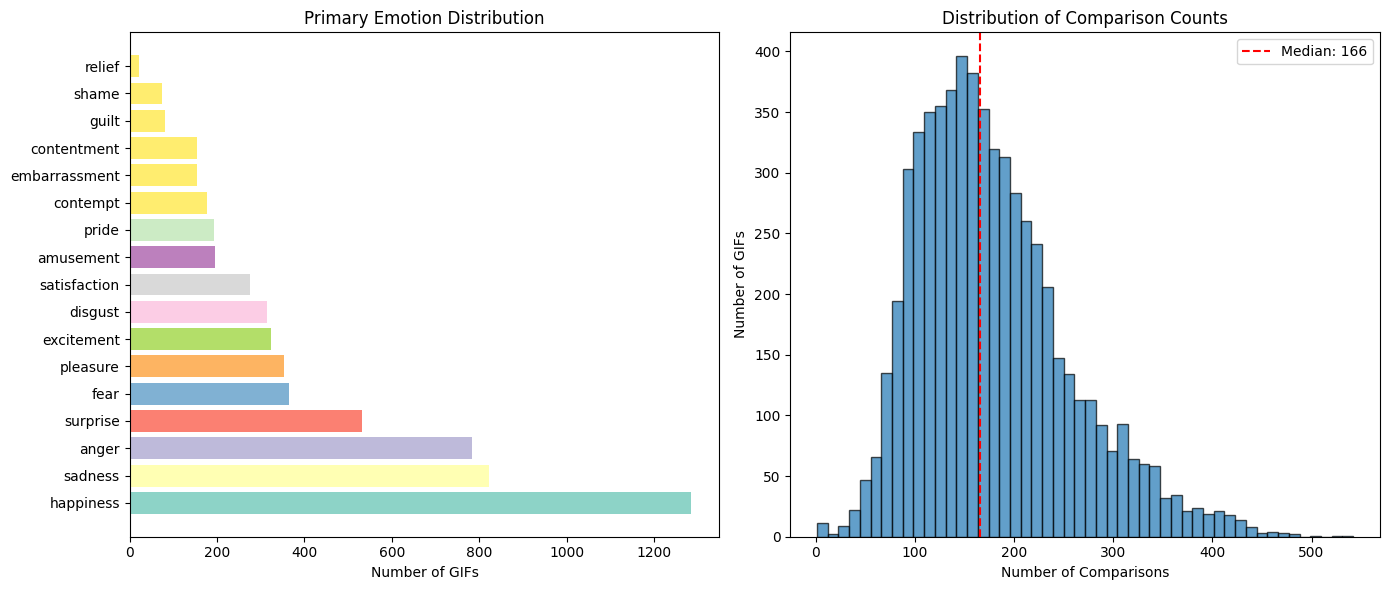

 Dataset saved as 'dataset_overview.png'


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
train_df = pd.read_csv('gifgif_emotion_labels.csv')

# Visualize emotion distribution
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
emotion_counts = train_df['primary_emotion'].value_counts()
colors = plt.cm.Set3(range(len(emotion_counts)))
plt.barh(emotion_counts.index, emotion_counts.values, color=colors)
plt.xlabel('Number of GIFs')
plt.title('Primary Emotion Distribution')
plt.tight_layout()

plt.subplot(1, 2, 2)
plt.hist(train_df['total_comparisons'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Comparisons')
plt.ylabel('Number of GIFs')
plt.title('Distribution of Comparison Counts')
plt.axvline(train_df['total_comparisons'].median(), color='red', 
            linestyle='--', label=f'Median: {train_df["total_comparisons"].median():.0f}')
plt.legend()

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print(f" Dataset saved as 'dataset_overview.png'")

In [14]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB 660.6 kB/s eta 0:00:13
   ---------------------------------------- 0.1/8.0 MB 975.2 kB/s eta 0:00:09
    --------------------------------------- 0.1/8.0 MB 1.6 MB/s eta 0:00:05
    --------------------------------------- 0.1/8.0 MB 1.6 MB/s eta 0:00:05
    --------------------------------------- 0.1/8.0 MB 1.6 MB/s eta 0:00:05
   - -------------------------------------- 0.2/8.0 MB 1.3 MB/s eta 0:00:06
   - -------------------------------------- 0.3/8.0 MB 1.2 MB/s eta 0:00:07
   - -------------------------------------- 0.4/8.0 MB 1.2 MB/s eta 0:00:07
   -- ------------------------------------- 0.4/8.0 MB 1.4 MB/s eta 0:00:06
   -- ------------------------------------- 0.5/8.0 MB 1.5 MB/s eta 0:00:06
   --- ------------------------------------ 0.6/8.0 MB 1.6 MB/s eta 0:00:05
   --- ------------------------------------ 0.7/8.0 MB 1.7 MB/s eta 0:00:05
   --- --------


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load dataset
train_df = pd.read_csv('gifgif_emotion_labels.csv')

print("="*60)
print("ORIGINAL DATASET")
print("="*60)
print(f"Total GIFs: {len(train_df)}")
print(f"Total emotions: {train_df['primary_emotion'].nunique()}")
print(f"\nEmotion distribution:")
print(train_df['primary_emotion'].value_counts())

# Filter: Keep emotions with at least 150 samples
MIN_SAMPLES = 150
emotion_counts = train_df['primary_emotion'].value_counts()
valid_emotions = emotion_counts[emotion_counts >= MIN_SAMPLES].index

balanced_df = train_df[train_df['primary_emotion'].isin(valid_emotions)].copy()

print("\n" + "="*60)
print("FILTERED DATASET (MIN 150 SAMPLES)")
print("="*60)
print(f"Total GIFs: {len(balanced_df)}")
print(f"Total emotions: {balanced_df['primary_emotion'].nunique()}")
print(f"Removed {len(train_df) - len(balanced_df)} GIFs")

print(f"\n KEPT emotions ({len(valid_emotions)}):")
print(balanced_df['primary_emotion'].value_counts())

removed_emotions = set(train_df['primary_emotion'].unique()) - set(valid_emotions)
print(f"\n REMOVED emotions ({len(removed_emotions)}):")
for emotion in removed_emotions:
    count = len(train_df[train_df['primary_emotion'] == emotion])
    print(f"  {emotion}: {count} samples")

# Save balanced dataset
balanced_df.to_csv('gifgif_balanced.csv', index=False)
print(f"\n Saved balanced dataset to 'gifgif_balanced.csv'")

ORIGINAL DATASET
Total GIFs: 6101
Total emotions: 17

Emotion distribution:
primary_emotion
happiness        1285
sadness           823
anger             783
surprise          531
fear              364
pleasure          353
excitement        323
disgust           314
satisfaction      275
amusement         196
pride             192
contempt          176
embarrassment     155
contentment       154
guilt              80
shame              75
relief             22
Name: count, dtype: int64

FILTERED DATASET (MIN 150 SAMPLES)
Total GIFs: 5924
Total emotions: 14
Removed 177 GIFs

 KEPT emotions (14):
primary_emotion
happiness        1285
sadness           823
anger             783
surprise          531
fear              364
pleasure          353
excitement        323
disgust           314
satisfaction      275
amusement         196
pride             192
contempt          176
embarrassment     155
contentment       154
Name: count, dtype: int64

 REMOVED emotions (3):
  relief: 22 samples
  

In [16]:
# Create stratified splits
print("\n" + "="*60)
print("CREATING TRAIN/VAL/TEST SPLITS")
print("="*60)

# 70% train, 15% val, 15% test
train_data, temp_data = train_test_split(
    balanced_df,
    test_size=0.3,
    stratify=balanced_df['primary_emotion'],
    random_state=42
)

val_data, test_data = train_test_split(
    temp_data,
    test_size=0.5,
    stratify=temp_data['primary_emotion'],
    random_state=42
)

print(f"\n Split sizes:")
print(f"  Train: {len(train_data):4d} GIFs (70.0%)")
print(f"  Val:   {len(val_data):4d} GIFs (15.0%)")
print(f"  Test:  {len(test_data):4d} GIFs (15.0%)")
print(f"  Total: {len(train_data) + len(val_data) + len(test_data):4d} GIFs")

# Verify stratification worked
print(f"\n Emotion distribution across splits:")
print(f"\n{'Emotion':<15} {'Train':<8} {'Val':<8} {'Test':<8} {'Total':<8}")
print("-" * 55)

for emotion in sorted(balanced_df['primary_emotion'].unique()):
    train_count = len(train_data[train_data['primary_emotion'] == emotion])
    val_count = len(val_data[val_data['primary_emotion'] == emotion])
    test_count = len(test_data[test_data['primary_emotion'] == emotion])
    total_count = train_count + val_count + test_count
    
    print(f"{emotion:<15} {train_count:<8} {val_count:<8} {test_count:<8} {total_count:<8}")

# Save splits
train_data.to_csv('train_split.csv', index=False)
val_data.to_csv('val_split.csv', index=False)
test_data.to_csv('test_split.csv', index=False)

print(f"\n Splits saved:")
print(f"  - train_split.csv")
print(f"  - val_split.csv")
print(f"  - test_split.csv")


CREATING TRAIN/VAL/TEST SPLITS

 Split sizes:
  Train: 4146 GIFs (70.0%)
  Val:    889 GIFs (15.0%)
  Test:   889 GIFs (15.0%)
  Total: 5924 GIFs

 Emotion distribution across splits:

Emotion         Train    Val      Test     Total   
-------------------------------------------------------
amusement       137      29       30       196     
anger           548      118      117      783     
contempt        123      27       26       176     
contentment     108      23       23       154     
disgust         220      47       47       314     
embarrassment   109      23       23       155     
excitement      226      49       48       323     
fear            255      54       55       364     
happiness       899      193      193      1285    
pleasure        247      53       53       353     
pride           134      29       29       192     
sadness         576      123      124      823     
satisfaction    192      42       41       275     
surprise        372      79   

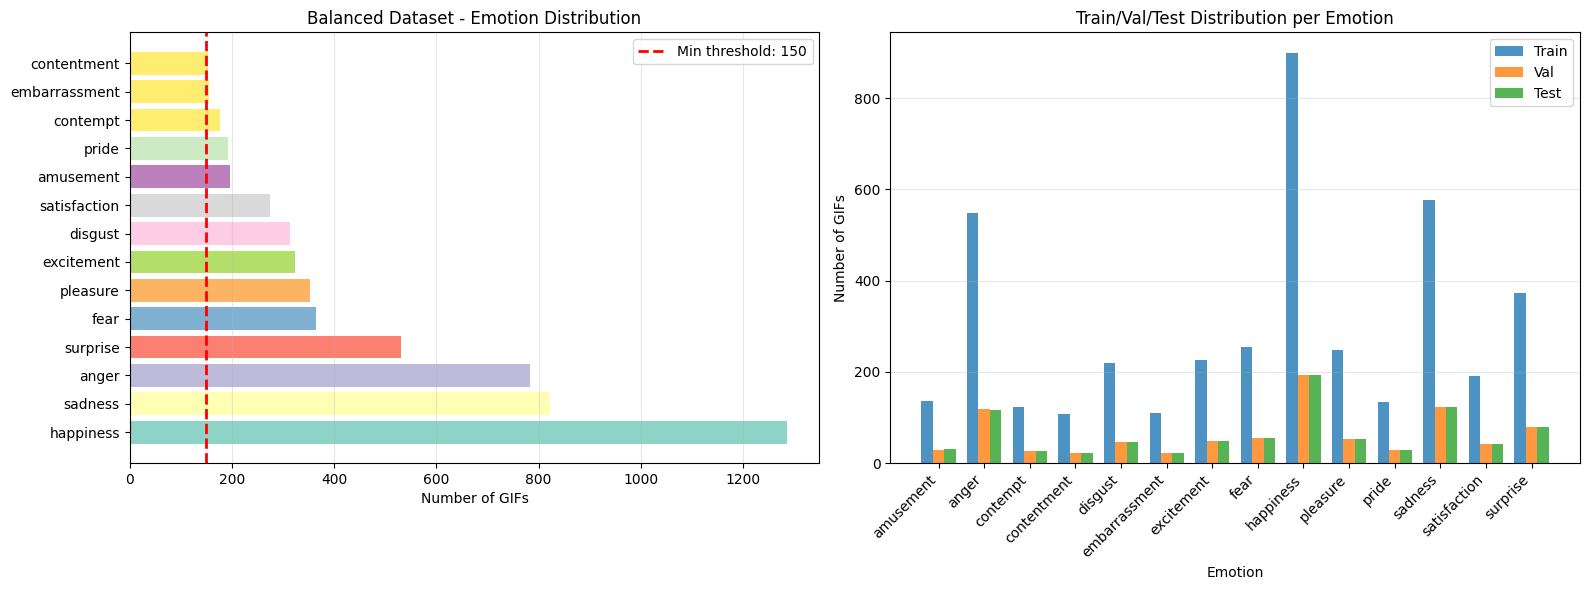


 Visualization saved as 'balanced_dataset_splits.png'


In [17]:
# Visualize balanced dataset
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Emotion distribution in balanced dataset
emotion_counts = balanced_df['primary_emotion'].value_counts()
colors = plt.cm.Set3(range(len(emotion_counts)))
axes[0].barh(emotion_counts.index, emotion_counts.values, color=colors)
axes[0].set_xlabel('Number of GIFs')
axes[0].set_title('Balanced Dataset - Emotion Distribution')
axes[0].grid(axis='x', alpha=0.3)
axes[0].axvline(x=MIN_SAMPLES, color='red', linestyle='--', linewidth=2, 
                label=f'Min threshold: {MIN_SAMPLES}')
axes[0].legend()

# Right: Train/Val/Test distribution
split_data = {
    'Train': train_data['primary_emotion'].value_counts(),
    'Val': val_data['primary_emotion'].value_counts(),
    'Test': test_data['primary_emotion'].value_counts()
}

import numpy as np
emotions = sorted(balanced_df['primary_emotion'].unique())
x = np.arange(len(emotions))
width = 0.25

for i, (split_name, counts) in enumerate(split_data.items()):
    values = [counts.get(emotion, 0) for emotion in emotions]
    axes[1].bar(x + i*width, values, width, label=split_name, alpha=0.8)

axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Number of GIFs')
axes[1].set_title('Train/Val/Test Distribution per Emotion')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(emotions, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('balanced_dataset_splits.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Visualization saved as 'balanced_dataset_splits.png'")

In [19]:
# Check data quality in each split
print("\n" + "="*60)
print("DATA QUALITY CHECK")
print("="*60)

for split_name, split_df in [('Train', train_data), ('Val', val_data), ('Test', test_data)]:
    print(f"\n{split_name} Set:")
    print(f"  Total GIFs: {len(split_df)}")
    print(f"  Emotions: {split_df['primary_emotion'].nunique()}")
    print(f"  Avg comparisons/GIF: {split_df['total_comparisons'].mean():.1f}")
    print(f"  Min comparisons: {split_df['total_comparisons'].min()}")
    print(f"  Max comparisons: {split_df['total_comparisons'].max()}")
    
    # Check for any GIFs with very few comparisons
    low_quality = split_df[split_df['total_comparisons'] < 50]
    if len(low_quality) > 0:
        print(f"  ️ GIFs with <50 comparisons: {len(low_quality)}")
    else:
        print(f"   All GIFs have ≥50 comparisons")



DATA QUALITY CHECK

Train Set:
  Total GIFs: 4146
  Emotions: 14
  Avg comparisons/GIF: 179.5
  Min comparisons: 1
  Max comparisons: 542
  ️ GIFs with <50 comparisons: 39

Val Set:
  Total GIFs: 889
  Emotions: 14
  Avg comparisons/GIF: 179.2
  Min comparisons: 1
  Max comparisons: 460
  ️ GIFs with <50 comparisons: 9

Test Set:
  Total GIFs: 889
  Emotions: 14
  Avg comparisons/GIF: 176.8
  Min comparisons: 1
  Max comparisons: 439
  ️ GIFs with <50 comparisons: 13
